# Тест 1 — влияние архитектуры PINN

In [ ]:

import os, sys
assert os.path.exists('pinn_core.py'),     'нужен pinn_core.py в корне сессии'
assert os.path.exists('cell_viz_v4.py'),   'нужен cell_viz_v4.py'
assert os.path.exists('tests_common.py'),  'нужен tests_common.py'

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from pathlib import Path


%run -i pinn_core.py
%run -i cell_viz_v4.py
%run -i tests_common.py

print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)

RESULTS_DIR = Path('results'); RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR   = Path('plots');   PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_PATH = RESULTS_DIR / 'test1_architecture.pkl'

PINN Solver loaded
tests_common.py loaded
Device: cuda
Torch: 2.6.0+cu124


## Конфигурация эксперимента

In [ ]:

LAYERS_GRID = [1, 2, 4, 6]
HIDDEN_GRID = [16, 48, 96, 144]


TRAIN_KWARGS = dict(
    n_epochs_adam=6000,
    lbfgs_max_iter=1500,
    use_lbfgs=True,
    early_stop_patience=300,
    early_stop_rtol=1e-9,
    lr=1e-3,
    sampling='random',
    scheduler_type='cosine',
)


TASKS = [task_hyperbolic(), task_elliptic(), task_parabolic_2d()]


CONFIGS = []
for L in LAYERS_GRID:
    for H in HIDDEN_GRID:
        CONFIGS.append({
            'config_id': f'L{L}_H{H}',
            'arch_kwargs': {'num_hidden_layers': L, 'hidden_size': H},
            'points_kwargs': {},
        })


HISTORY_FOR = ['L1_H16', 'L2_H48', 'L4_H96', 'L6_H144', 'L4_H48']

print(f'{len(LAYERS_GRID)}×{len(HIDDEN_GRID)} = {len(CONFIGS)} конфигов '
      f'× {len(TASKS)} задач = {len(CONFIGS) * len(TASKS)} прогонов')

4×4 = 16 конфигов × 3 задач = 48 прогонов


## Главный эксперимент

In [4]:
results = run_grid(
    tasks=TASKS,
    configs=CONFIGS,
    train_kwargs=TRAIN_KWARGS,
    save_path=RESULTS_PATH,
    save_history_for=HISTORY_FOR,
    seed=42,
    verbose=True,
)
print(f'\n{len(results)} результатов сохранено в {RESULTS_PATH}')

[1/48] hyperbolic    / L1_H16                (elapsed 0.0min, ETA 0.0min)
  rel_l2=2.639e-04  max|Δ|=4.021e-04  time=93.7s  params=65
[2/48] hyperbolic    / L1_H48                (elapsed 1.6min, ETA 71.8min)
  rel_l2=6.155e-04  max|Δ|=1.017e-03  time=87.4s  params=193
[3/48] hyperbolic    / L1_H96                (elapsed 3.0min, ETA 132.8min)
  rel_l2=2.259e-04  max|Δ|=4.083e-04  time=88.4s  params=385
[4/48] hyperbolic    / L1_H144               (elapsed 4.5min, ETA 188.6min)
  rel_l2=9.189e-04  max|Δ|=2.112e-03  time=87.3s  params=577
[5/48] hyperbolic    / L2_H16                (elapsed 5.9min, ETA 237.8min)
  rel_l2=5.082e-03  max|Δ|=1.130e-02  time=112.7s  params=337
[6/48] hyperbolic    / L2_H48                (elapsed 7.8min, ETA 297.3min)
  rel_l2=1.960e-03  max|Δ|=3.339e-03  time=98.5s  params=2545
[7/48] hyperbolic    / L2_H96                (elapsed 9.5min, ETA 340.8min)
  rel_l2=5.721e-04  max|Δ|=1.417e-03  time=93.9s  params=9697
[8/48] hyperbolic    / L2_H144            

## Сводка результатов

In [ ]:

results = load_results(RESULTS_PATH)
print(f'Загружено {len(results)} результатов')

print_summary_table(results, sort_by='rel_l2', top_k=5)

Загружено 48 результатов
СВОДКА: 48 прогонов

>>> Задача: hyperbolic   (16 OK, 0 FAILED)

  Топ-5 (по rel_l2):
config_id    rel_l2   abs_max    time_s  n_params
   L1_H96 2.259e-04 4.083e-04 8.843e+01       385
   L1_H16 2.639e-04 4.021e-04 9.367e+01        65
   L6_H96 3.435e-04 8.343e-04 1.776e+02     46945
   L4_H96 3.632e-04 5.568e-04 1.305e+02     28321
   L4_H48 4.907e-04 1.120e-03 1.311e+02      7249

  Хуже всех:
config_id    rel_l2   abs_max    time_s  n_params
   L2_H48 1.960e-03 3.339e-03 9.848e+01      2545
  L4_H144 2.286e-03 3.928e-03 1.363e+02     63217
   L2_H16 5.082e-03 1.130e-02 1.127e+02       337

>>> Задача: elliptic   (16 OK, 0 FAILED)

  Топ-5 (по rel_l2):
config_id    rel_l2   abs_max    time_s  n_params
   L6_H96 2.033e-04 7.347e-04 2.205e+02     46945
   L2_H96 4.383e-04 6.816e-04 1.160e+02      9697
  L6_H144 7.363e-04 1.650e-03 2.216e+02    104977
   L2_H16 9.058e-04 2.879e-03 1.147e+02       337
   L2_H48 9.696e-04 2.577e-03 1.154e+02      2545

  Хуже все

In [ ]:
df = results_to_dataframe(results)
print(f'\nDataFrame: {df.shape[0]} строк × {df.shape[1]} столбцов')
print('Колонки:', list(df.columns))


DataFrame: 48 строк × 19 столбцов
Колонки: ['task', 'config_id', 'rel_l2', 'abs_max', 'final_total', 'final_residual', 'final_conditions', 'time_s', 'n_params', 'failed', 'err_msg', 'arch.hidden_size', 'arch.num_hidden_layers', 'arch.activation', 'arch.loss_weighting', 'arch.lambda_res', 'arch.lambda_cond', 'points.n_collocation', 'points.n_condition']


## Heatmap rel L2


In [ ]:
%run -i pinn_core.py
%run -i cell_viz_v4.py
%run -i tests_common.py

from pathlib import Path
RESULTS_DIR = Path('results')
PLOTS_DIR   = Path('plots'); PLOTS_DIR.mkdir(exist_ok=True)

results = load_results(RESULTS_DIR / 'test1_architecture.pkl')

TASKS = [task_hyperbolic(), task_elliptic(), task_parabolic_2d()]
LAYERS_GRID = [1, 2, 4, 6]
HIDDEN_GRID = [16, 48, 96, 144]

PINN Solver loaded
tests_common.py loaded


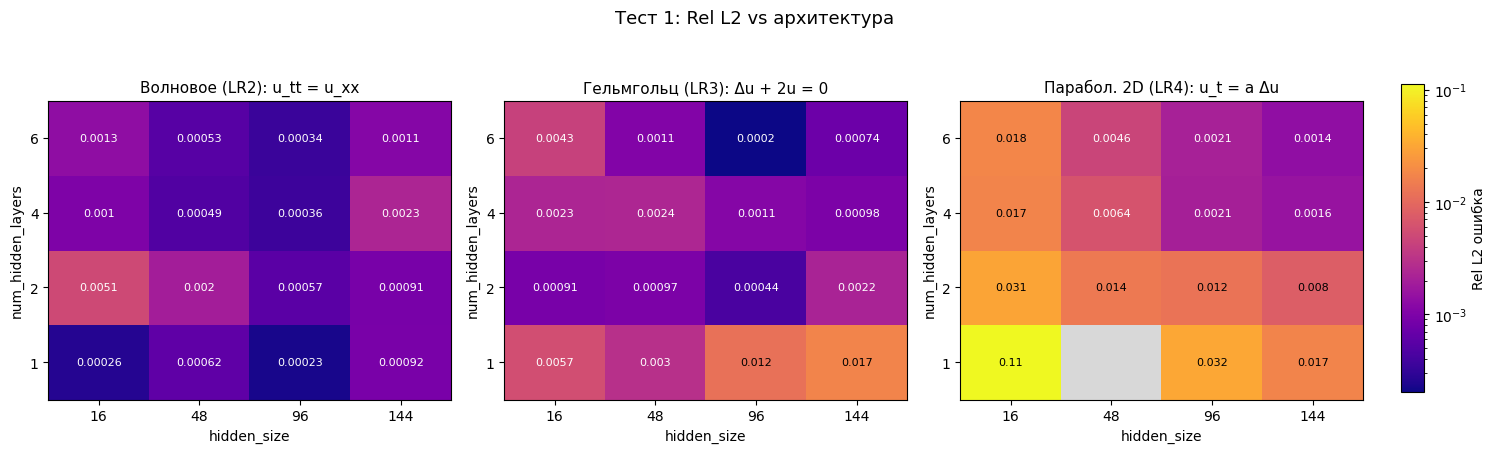

In [9]:
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=HIDDEN_GRID, y_grid=LAYERS_GRID,
    x_key='arch.hidden_size', y_key='arch.num_hidden_layers',
    value_key='rel_l2', value_label='Rel L2 ошибка',
    x_label='hidden_size', y_label='num_hidden_layers',
    log_color=True, cmap='plasma',
    title='Тест 1: Rel L2 vs архитектура',
    save_path=PLOTS_DIR / 'test1_heatmap_rel_l2.png', skip_failed=True,
)

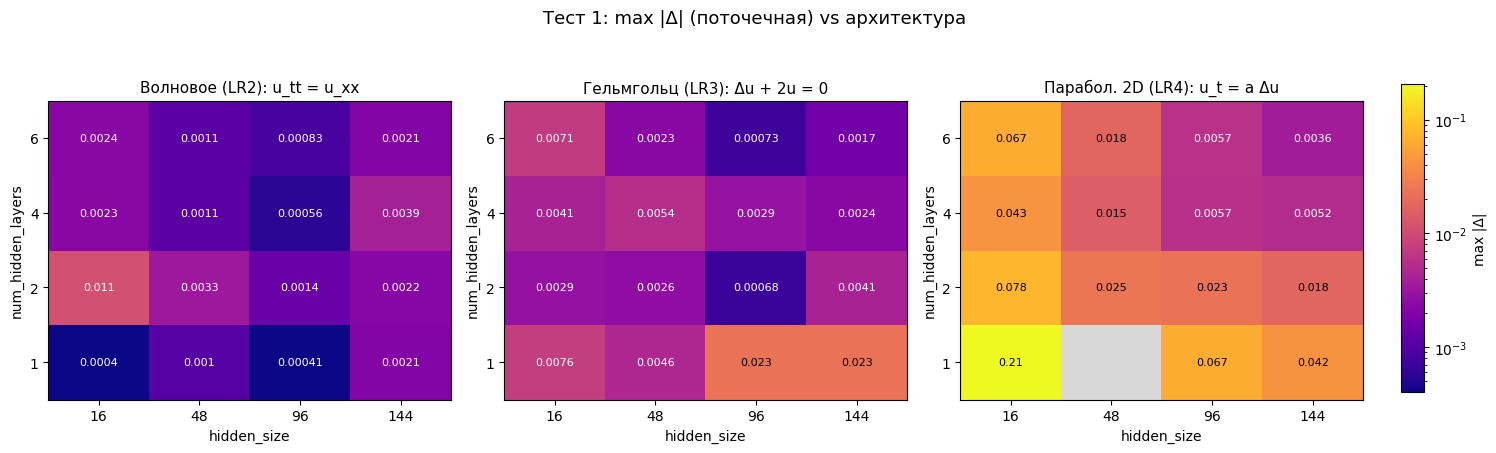

In [11]:
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=HIDDEN_GRID, y_grid=LAYERS_GRID,
    x_key='arch.hidden_size', y_key='arch.num_hidden_layers',
    value_key='abs_max', value_label='max |Δ|',
    x_label='hidden_size', y_label='num_hidden_layers',
    log_color=True, cmap='plasma',
    title='Тест 1: max |Δ| (поточечная) vs архитектура',
    save_path=PLOTS_DIR / 'test1_heatmap_abs_max.png', skip_failed=True,
)

## Heatmap времени обучения


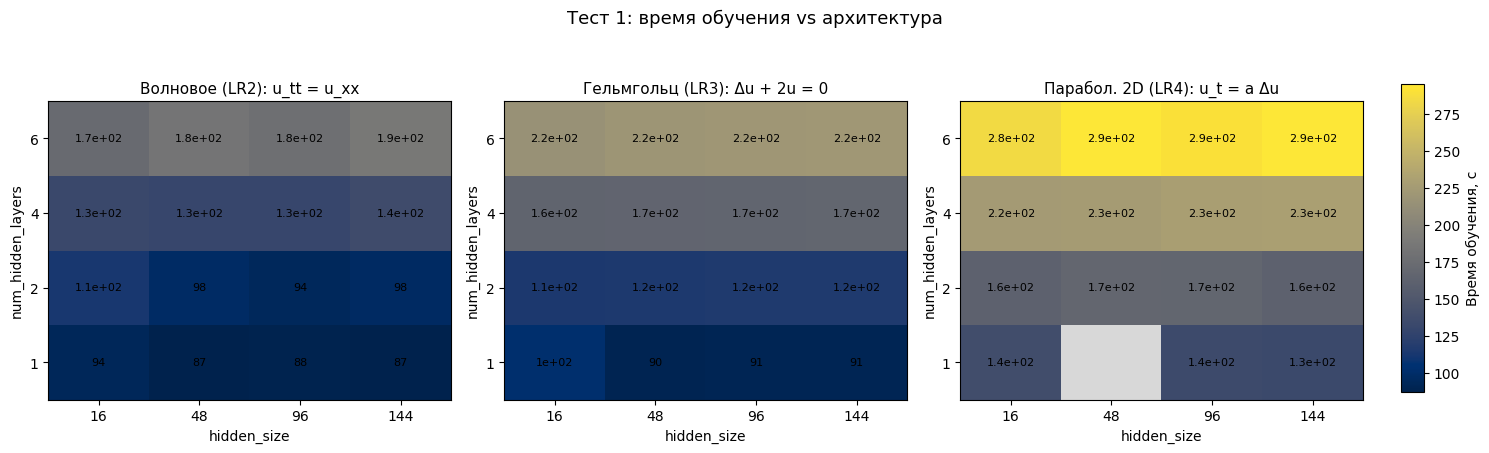

In [12]:
plot_heatmap_3tasks(
    results, TASKS,
    x_grid=HIDDEN_GRID, y_grid=LAYERS_GRID,
    x_key='arch.hidden_size', y_key='arch.num_hidden_layers',
    value_key='time_s', value_label='Время обучения, с',
    x_label='hidden_size', y_label='num_hidden_layers',
    log_color=False, cmap='cividis',
    title='Тест 1: время обучения vs архитектура',
    save_path=PLOTS_DIR / 'test1_heatmap_time.png',skip_failed=True,
)

## Pareto-фронт: точность vs число параметров


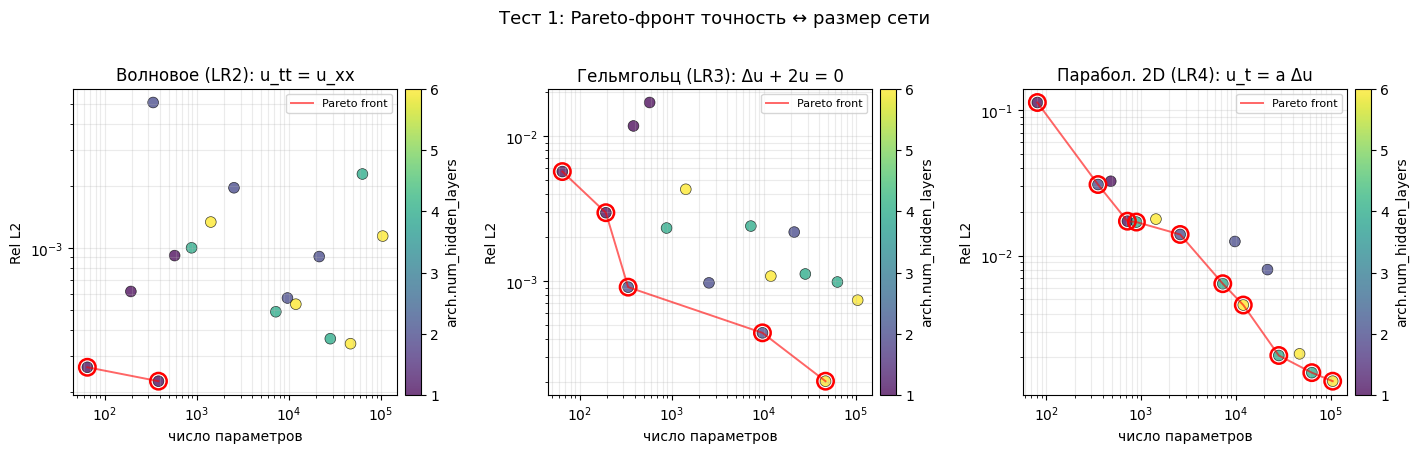

In [13]:
plot_pareto_3tasks(
    results, TASKS,
    x_key='n_params', y_key='rel_l2',
    color_key='arch.num_hidden_layers',
    x_label='число параметров', y_label='Rel L2',
    title='Тест 1: Pareto-фронт точность ↔ размер сети',
    save_path=PLOTS_DIR / 'test1_pareto.png',
)

## Кривые training loss

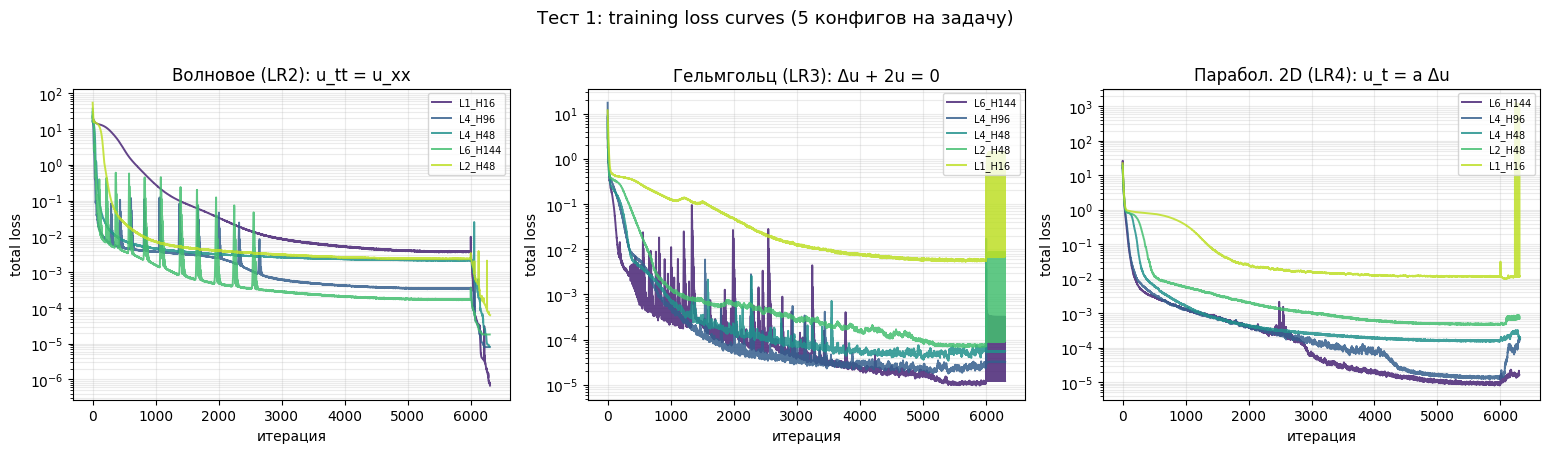

In [18]:
plot_loss_curves_per_task(
    results, TASKS, n_show=5,
    title='Тест 1: training loss curves (5 конфигов на задачу)',
    save_path=PLOTS_DIR / 'test1_loss_curves.png',
)